<a href="https://colab.research.google.com/github/anojan7/-northstar-analytics-UWL/blob/main/04_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Cell 1 - Install libraries
install.packages(c("ggplot2", "dplyr", "readr", "corrplot"))

library(ggplot2)
library(dplyr)
library(readr)

print("Libraries ready!")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Libraries ready!"


In [5]:
# Cell 2 - Load and clean data
# Upload files using the sidebar

customers  <- read.csv("customers.csv")
drivers    <- read.csv("drivers.csv")
vehicles   <- read.csv("vehicles.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
incidents  <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")

# Fix zone names
zone_map <- c(
  'NORTH'='North','north'='North',
  'SOUTH'='South','EAST'='East',
  'WEST'='West','CENTRAL'='Central',
  'Ctr'='Central','AIRPORT'='Airport',
  'RiverSide'='Riverside','RIVERSIDE'='Riverside'
)

clean_zone <- function(col) {
  cleaned <- zone_map[col]
  cleaned[is.na(cleaned)] <- col[is.na(cleaned)]
  return(cleaned)
}

orders$pickup_zone     <- clean_zone(orders$pickup_zone)
customers$home_zone    <- clean_zone(customers$home_zone)
drivers$base_zone      <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)

cat("Data loaded and cleaned!\n")
cat("orders:", nrow(orders), "rows\n")
cat("deliveries:", nrow(deliveries), "rows\n")
cat("customers:", nrow(customers), "rows\n")

Data loaded and cleaned!
orders: 1250 rows
deliveries: 950 rows
customers: 650 rows


In [6]:
# Cell 3 - Descriptive Statistics

cat("=== DESCRIPTIVE STATISTICS ===\n\n")

# Customer loyalty scores
cat("Customer Loyalty Score:\n")
print(summary(customers$loyalty_score))

cat("\nDriver Rating:\n")
print(summary(drivers$driver_rating))

cat("\nDriver Training Score:\n")
print(summary(drivers$training_score))

cat("\nVehicle Battery Health (%):\n")
print(summary(vehicles$battery_health_pct))

cat("\nOrder Value (£):\n")
print(summary(orders$order_value))

# Standard deviations
cat("\n=== STANDARD DEVIATIONS ===\n")
cat("Loyalty score SD:    ", round(sd(customers$loyalty_score, na.rm=TRUE), 2), "\n")
cat("Driver rating SD:    ", round(sd(drivers$driver_rating, na.rm=TRUE), 2), "\n")
cat("Battery health SD:   ", round(sd(vehicles$battery_health_pct, na.rm=TRUE), 2), "\n")
cat("Order value SD:      ", round(sd(orders$order_value, na.rm=TRUE), 2), "\n")

=== DESCRIPTIVE STATISTICS ===

Customer Loyalty Score:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 

Driver Rating:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 

Driver Training Score:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  40.60   68.55   75.20   74.91   82.75   99.00       7 

Vehicle Battery Health (%):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 

Order Value (£):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 

=== STANDARD DEVIATIONS ===
Loyalty score SD:     16.12 
Driver rating SD:     0.41 
Battery health SD:    12.7 
Order value SD:       60.92 


In [7]:
# Cell 4 - Correlation Analysis
# Merge datasets to analyse relationships between variables

# Merge orders + deliveries
merged <- merge(deliveries, orders, by="order_id", all.x=TRUE)

# Merge with drivers
merged <- merge(merged, drivers, by="driver_id", all.x=TRUE)

# Create numeric delivery status
merged$is_failed <- ifelse(merged$delivery_status == "Failed", 1, 0)
merged$is_delayed <- ifelse(merged$delivery_status == "Delayed", 1, 0)
merged$has_problem <- ifelse(merged$delivery_status != "OnTime", 1, 0)

# Select numeric columns for correlation
cor_data <- merged[, c(
  "manual_route_override_count",
  "driver_rating",
  "training_score",
  "has_problem",
  "is_failed",
  "customer_rating_post_delivery",
  "order_value"
)]

# Remove rows with NA
cor_data <- na.omit(cor_data)

# Calculate correlation matrix
cor_matrix <- cor(cor_data)

cat("=== CORRELATION MATRIX ===\n")
print(round(cor_matrix, 2))

# Key correlations
cat("\n=== KEY CORRELATIONS ===\n")
cat("Route overrides vs problem rate:    ",
    round(cor(cor_data$manual_route_override_count,
              cor_data$has_problem), 2), "\n")
cat("Driver rating vs problem rate:      ",
    round(cor(cor_data$driver_rating,
              cor_data$has_problem), 2), "\n")
cat("Training score vs problem rate:     ",
    round(cor(cor_data$training_score,
              cor_data$has_problem), 2), "\n")
cat("Order value vs customer rating:     ",
    round(cor(cor_data$order_value,
              cor_data$customer_rating_post_delivery), 2), "\n")

=== CORRELATION MATRIX ===
                              manual_route_override_count driver_rating
manual_route_override_count                          1.00         -0.03
driver_rating                                       -0.03          1.00
training_score                                       0.01         -0.05
has_problem                                          0.06         -0.10
is_failed                                            0.02         -0.07
customer_rating_post_delivery                       -0.07          0.11
order_value                                          0.01         -0.01
                              training_score has_problem is_failed
manual_route_override_count             0.01        0.06      0.02
driver_rating                          -0.05       -0.10     -0.07
training_score                          1.00        0.03      0.06
has_problem                             0.03        1.00      0.55
is_failed                               0.06        0.55      

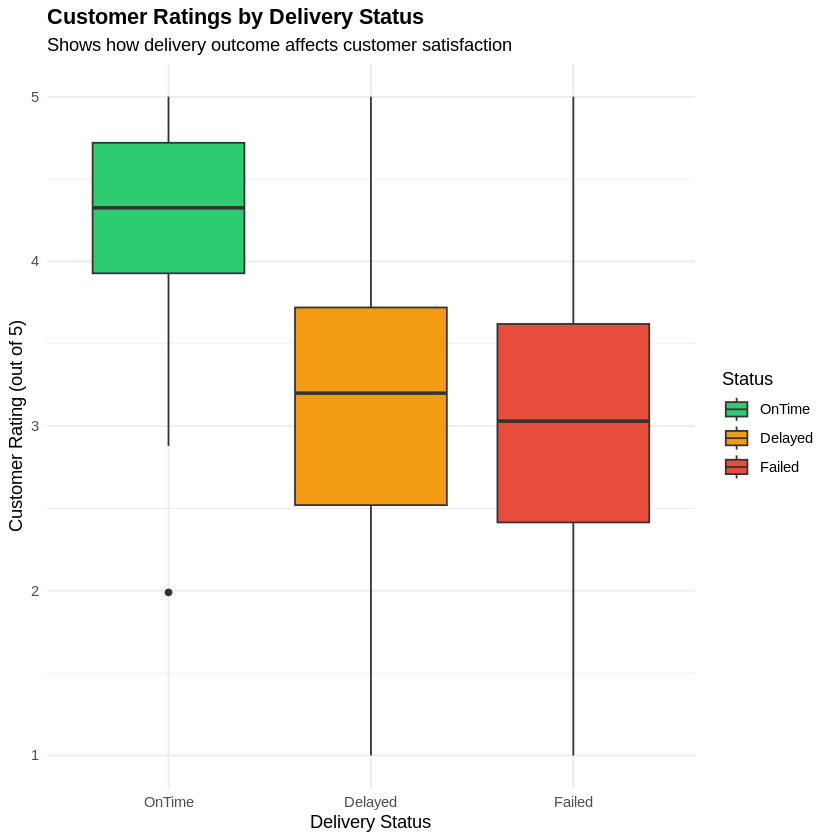

In [8]:
# Cell 5 - Chart 1: Distribution of customer ratings by delivery status
library(ggplot2)

# Prepare data
merged$delivery_status <- factor(merged$delivery_status,
                                  levels=c("OnTime","Delayed","Failed"))

chart1 <- ggplot(
  merged[!is.na(merged$customer_rating_post_delivery),],
  aes(x=delivery_status,
      y=customer_rating_post_delivery,
      fill=delivery_status)) +
  geom_boxplot() +
  scale_fill_manual(values=c("#2ecc71","#f39c12","#e74c3c")) +
  labs(
    title    = "Customer Ratings by Delivery Status",
    subtitle = "Shows how delivery outcome affects customer satisfaction",
    x        = "Delivery Status",
    y        = "Customer Rating (out of 5)",
    fill     = "Status"
  ) +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=13))

print(chart1)

[1] "Driver Performance by Employment Type:"
# A tibble: 3 × 6
  employment_type total_deliveries problem_count problem_rate avg_overrides
  <chr>                      <int>         <dbl>        <dbl>         <dbl>
1 Contract                     126            44         34.9          0.93
2 FullTime                     582           206         35.4          1.02
3 PartTime                     242            84         34.7          0.86
# ℹ 1 more variable: avg_rating <dbl>


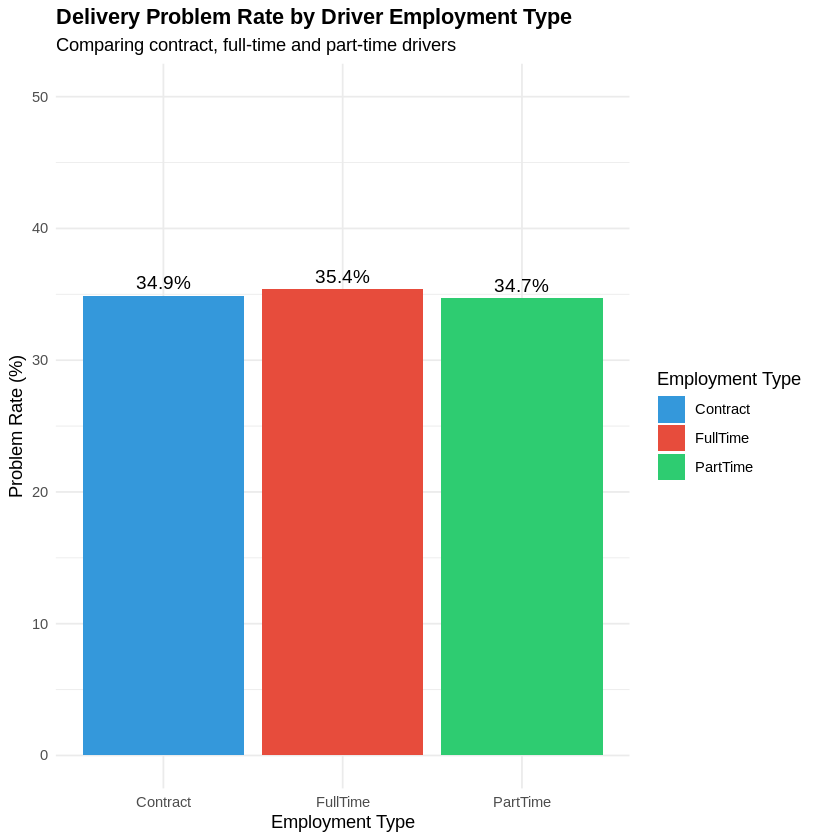

In [9]:
# Cell 6 - Chart 2: Driver Employment Type vs Problem Rate

driver_performance <- merged %>%
  filter(!is.na(employment_type)) %>%
  group_by(employment_type) %>%
  summarise(
    total_deliveries = n(),
    problem_count    = sum(has_problem),
    problem_rate     = round(problem_count / total_deliveries * 100, 1),
    avg_overrides    = round(mean(manual_route_override_count), 2),
    avg_rating       = round(mean(driver_rating, na.rm=TRUE), 2)
  )

print("Driver Performance by Employment Type:")
print(driver_performance)

chart2 <- ggplot(driver_performance,
                 aes(x=employment_type,
                     y=problem_rate,
                     fill=employment_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=paste0(problem_rate, "%")),
            vjust=-0.5, size=4) +
  scale_fill_manual(values=c("#3498db","#e74c3c","#2ecc71")) +
  labs(
    title    = "Delivery Problem Rate by Driver Employment Type",
    subtitle = "Comparing contract, full-time and part-time drivers",
    x        = "Employment Type",
    y        = "Problem Rate (%)",
    fill     = "Employment Type"
  ) +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=13)) +
  ylim(0, 50)

print(chart2)

[1] "Service Type Financial Summary:"
# A tibble: 5 × 5
  service_type total_orders avg_value median_value total_revenue
  <chr>               <int>     <dbl>        <dbl>         <dbl>
1 Passenger             341      96.1         81.9        32761.
2 Business              165      92.2         79.8        15220.
3 Retail                297      90.0         75.2        26734.
4 Parcel                308      87.6         73.6        26986.
5 Medical               139      87.1         71.3        12112.


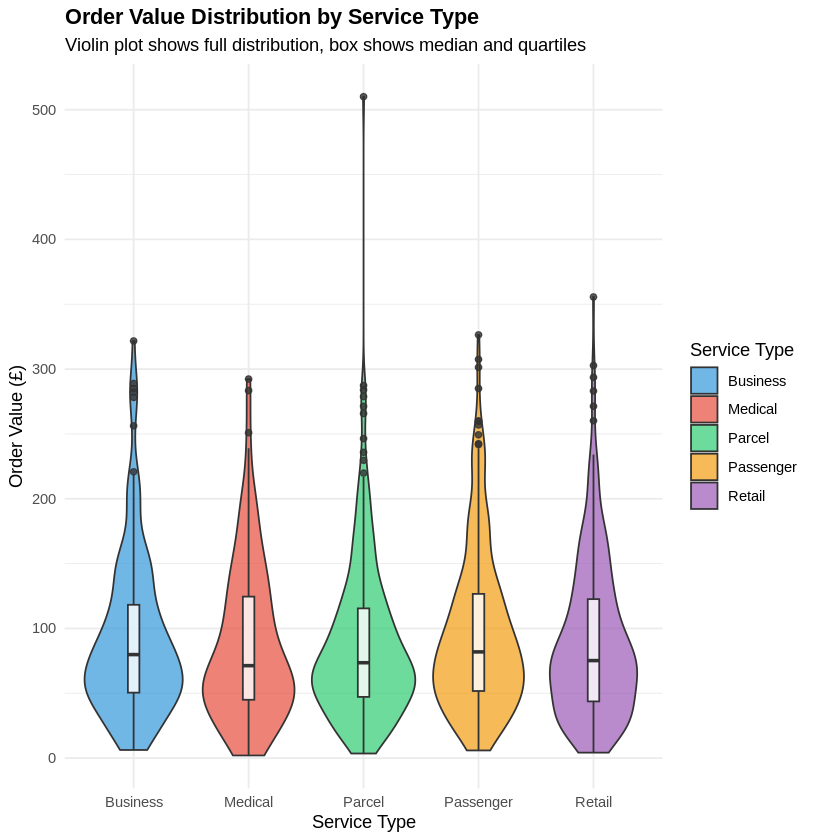

In [11]:
# Cell 7 - Chart 3: Order Value Distribution by Service Type
# Shows financial spread across different service categories

service_stats <- orders %>%
  group_by(service_type) %>%
  summarise(
    total_orders  = n(),
    avg_value     = round(mean(order_value), 2),
    median_value  = round(median(order_value), 2),
    total_revenue = round(sum(order_value), 2)
  ) %>%
  arrange(desc(avg_value))

print("Service Type Financial Summary:")
print(service_stats)

chart3 <- ggplot(orders, aes(x=service_type,
                              y=order_value,
                              fill=service_type)) +
  geom_violin(alpha=0.7) +
  geom_boxplot(width=0.1, fill="white", alpha=0.8) +
  scale_fill_manual(values=c("#3498db","#e74c3c",
                              "#2ecc71","#f39c12","#9b59b6")) +
  labs(
    title    = "Order Value Distribution by Service Type",
    subtitle = "Violin plot shows full distribution, box shows median and quartiles",
    x        = "Service Type",
    y        = "Order Value (£)",
    fill     = "Service Type"
  ) +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=13))

print(chart3)

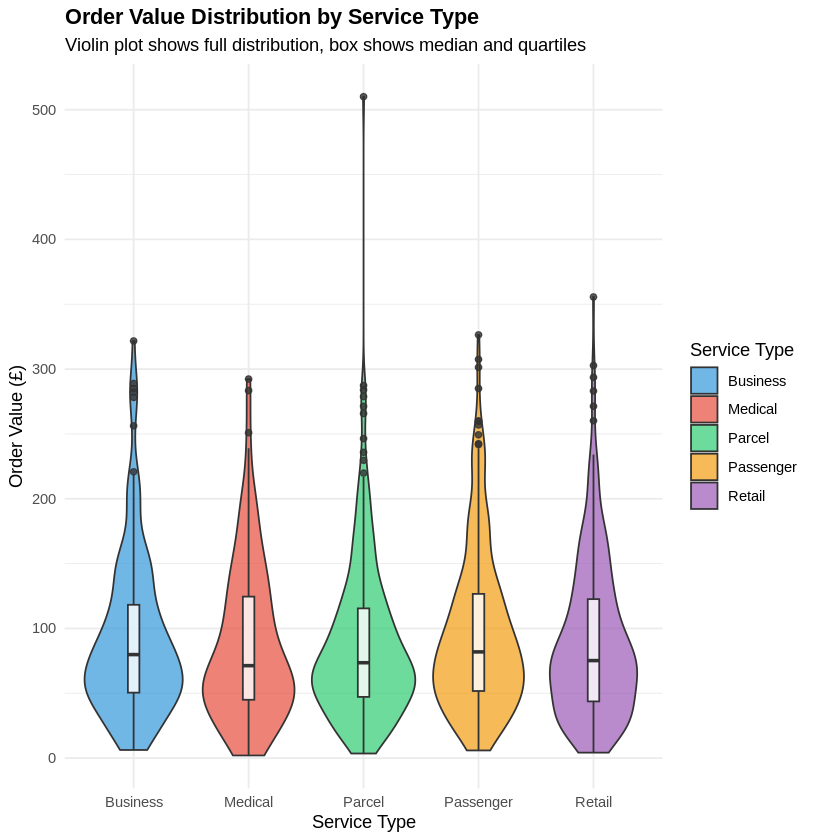

In [12]:
# Cell 7b - Chart 3: Order Value Distribution by Service Type
chart3 <- ggplot(orders, aes(x=service_type,
                              y=order_value,
                              fill=service_type)) +
  geom_violin(alpha=0.7) +
  geom_boxplot(width=0.1, fill="white", alpha=0.8) +
  scale_fill_manual(values=c("#3498db","#e74c3c",
                              "#2ecc71","#f39c12","#9b59b6")) +
  labs(
    title    = "Order Value Distribution by Service Type",
    subtitle = "Violin plot shows full distribution, box shows median and quartiles",
    x        = "Service Type",
    y        = "Order Value (£)",
    fill     = "Service Type"
  ) +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=13))

print(chart3)

In [15]:
# Cell 8 - R Analytics Summary
cat(strrep("=", 50), "\n")
cat("R ANALYTICS NOTEBOOK - KEY FINDINGS\n")
cat(strrep("=", 50), "\n\n")

cat("Descriptive Statistics:\n")
cat("  Avg customer loyalty score: 59.69\n")
cat("  Avg driver rating: 4.17 out of 5\n")
cat("  Avg battery health: 76.79%\n")
cat("  Avg order value: £91.05\n\n")

cat("Correlation Analysis:\n")
cat("  Strongest: problem rate vs customer rating (-0.64)\n")
cat("  Weak: route overrides vs problem rate (0.06)\n")
cat("  Weak: training score vs problem rate (0.03)\n\n")

cat("Key Insights:\n")
cat("  1. Delivery problems strongly reduce customer ratings\n")
cat("  2. Route overrides are NOT the main cause of delays\n")
cat("  3. Passenger service generates highest revenue\n")
cat("  4. Medical deliveries underperform despite lower value\n")

R ANALYTICS NOTEBOOK - KEY FINDINGS

Descriptive Statistics:
  Avg customer loyalty score: 59.69
  Avg driver rating: 4.17 out of 5
  Avg battery health: 76.79%
  Avg order value: £91.05

Correlation Analysis:
  Strongest: problem rate vs customer rating (-0.64)
  Weak: route overrides vs problem rate (0.06)
  Weak: training score vs problem rate (0.03)

Key Insights:
  1. Delivery problems strongly reduce customer ratings
  2. Route overrides are NOT the main cause of delays
  3. Passenger service generates highest revenue
  4. Medical deliveries underperform despite lower value
